# Import Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

import os
from PIL import Image

---

# Check Class Distribution

In [2]:
path = "../datasets"

splits = ["test", "train", "validation"]

for split in splits:
    
    split_path = os.path.join(path, split)
    
    print(split)
    
    for dataset_name in os.listdir(split_path):
        
        dataset_path = os.path.join(split_path, dataset_name)
        
        for class_name in os.listdir(dataset_path):
            
            class_path = os.path.join(dataset_path, class_name)
            
            images = os.listdir(class_path)
            
            print(f"  - {class_name:7} : {len(images)}")


test
  - closed  : 110
  - open    : 110
  - no_yawn : 110
  - yawn    : 109
train
  - closed  : 508
  - open    : 508
  - no_yawn : 507
  - yawn    : 506
validation
  - closed  : 108
  - open    : 108
  - no_yawn : 108
  - yawn    : 108


---

# Visualize Images

In [3]:
def show_images(split):

    plt.figure(figsize=(6, 6))

    image_count = 1

    split_path = os.path.join(path, split)

    for dataset_name in os.listdir(split_path):

        dataset_path = os.path.join(split_path, dataset_name)

        for class_name in os.listdir(dataset_path):

            class_path = os.path.join(dataset_path, class_name)

            images = os.listdir(class_path)

            random.shuffle(images)

            for file in images[:3]:

                image_path = os.path.join(class_path, file)

                image = Image.open(image_path)

                plt.subplot(4, 3, image_count)

                plt.imshow(image)

                plt.title(f"{class_name.upper()} {image.size}")

                plt.axis("off")

                image_count += 1

    plt.tight_layout()
    plt.show()

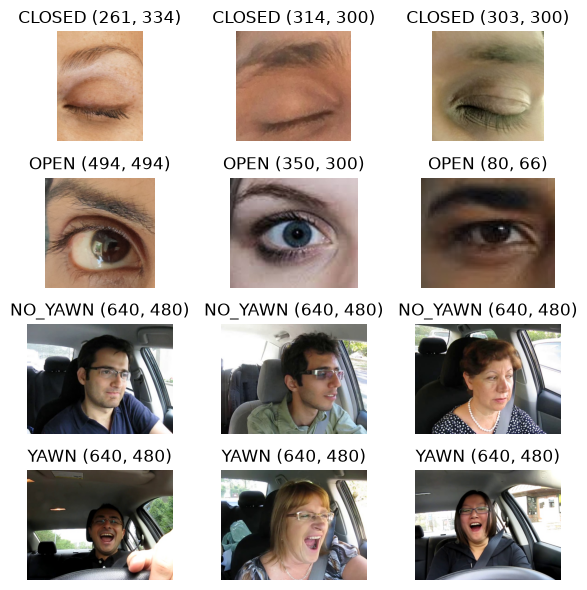

In [4]:
splits = ["train", "validation", "test"]

show_images(splits[0])

---

# Model Implement

## Import Modules

In [5]:
import tensorflow as tf

# For Loading Dataset
from tensorflow.keras.utils import image_dataset_from_directory

# For Data Normalization
from tensorflow.keras.layers import Rescaling

# For Data Argmentation
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomBrightness, RandomFlip

# For Build Layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout

I0000 00:00:1786276596.034065    4345 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load Dataset

In [6]:
# Define Image Size

image_height = 224
image_width = 224

### Eye Dataset

In [7]:
eye_train_dataset = image_dataset_from_directory(
    "../datasets/train/eye_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=True
)

eye_validation_dataset = image_dataset_from_directory(
    "../datasets/validation/eye_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

eye_test_dataset = image_dataset_from_directory(
    "../datasets/test/eye_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

Found 1016 files belonging to 2 classes.


I0000 00:00:1786276599.528788    4345 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4082 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 216 files belonging to 2 classes.
Found 220 files belonging to 2 classes.


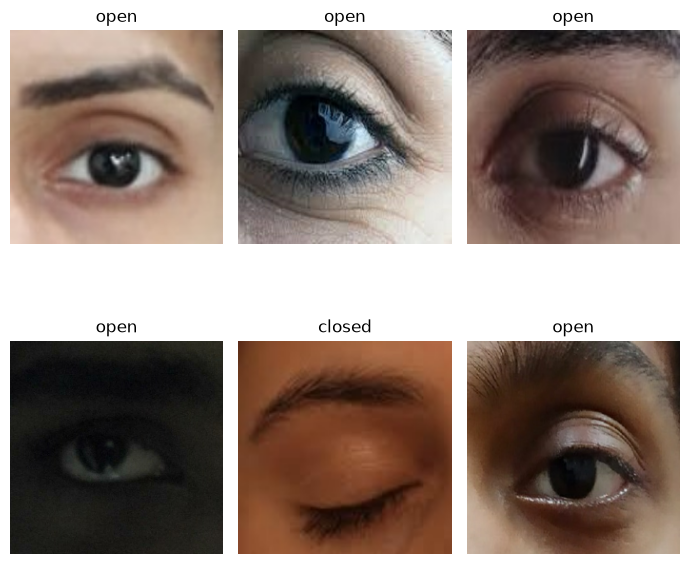

In [8]:
plt.figure(figsize=(7,7))

for images, labels in eye_train_dataset.take(1):
    
    for i in range(1, 7):
        
        image = images[i].numpy().astype("uint8")
        
        index = np.argmax(labels[i])
        class_name = eye_train_dataset.class_names[index]
        
        plt.subplot(2,3, i)
        
        plt.imshow(image)
        
        plt.title(class_name)
        
        plt.axis("off")
        
plt.tight_layout()
plt.show()

### Mouth Dataset

In [9]:
mouth_train_dataset = image_dataset_from_directory(
    "../datasets/train/mouth_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=True
)

mouth_validation_dataset = image_dataset_from_directory(
    "../datasets/validation/mouth_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

mouth_test_dataset = image_dataset_from_directory(
    "../datasets/test/mouth_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

Found 1013 files belonging to 2 classes.
Found 216 files belonging to 2 classes.
Found 219 files belonging to 2 classes.


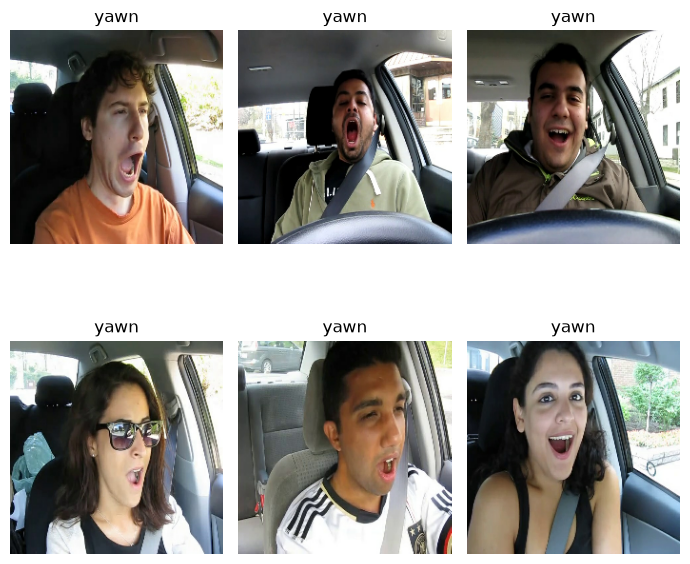

In [10]:
plt.figure(figsize=(7,7))

for images, labels in mouth_train_dataset.take(1):
    
    for i in range(1, 7):
        
        image = images[i].numpy().astype("uint8")
        
        index = np.argmax(labels[i])
        class_name = mouth_train_dataset.class_names[index]
        
        plt.subplot(2,3, i)
        
        plt.imshow(image)
        
        plt.title(class_name)
        
        plt.axis("off")
        
plt.tight_layout()
plt.show()

---

## Data Argmentation

In [11]:
data_argmentation = Sequential([
    RandomZoom(0.1),
    
    RandomRotation(0.1),
    
    RandomBrightness(0.1),
    
    RandomFlip("horizontal")
])

---

## Define the CNN Model

In [12]:
for images, labels in eye_train_dataset.take(1):
    
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32, 2)


In [13]:
def cnn_model(num_of_classes):
    
    model = Sequential([
        
        # Input Layer
        Input(shape=(image_height, image_width, 3)),
        
        # Data Argmentation
        data_argmentation,
        
        # Normalize pixel values
        Rescaling(1./255),
        
        # CNN Layer - 1
        Conv2D(filters = 32, kernel_size = (3,3), activation = "relu"),
        
        MaxPool2D(pool_size = (2,2)),
        
        # CNN Layer - 2
        Conv2D(filters = 64, kernel_size = (3,3), activation = "relu"),
        
        MaxPool2D(pool_size = (2,2)),
        
        # CNN Layer - 3
        Conv2D(filters = 128, kernel_size = (3,3), activation = "relu"),
        
        MaxPool2D(pool_size = (2,2)),
        
        # Flatten Layer
        Flatten(),
        
        # Hidden layer 1
        Dense(units = 128, activation = "relu"),
        
        # Dropout
        Dropout(0.3),
        
        # Output Layer
        Dense(units=num_of_classes, activation="softmax")
    ])
    
    return model

In [14]:
call_back = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

---

## Eye Model Implement

In [15]:
eye_model = cnn_model(2)

In [16]:
eye_model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [17]:
eye_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
eye_model_history = eye_model.fit(
    eye_train_dataset,
    validation_data = eye_validation_dataset,
    epochs = 20,
    callbacks = [call_back]
)

Epoch 1/20


/home/jeeva/miniconda3/envs/tf-gpu-conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786276608.183737    4434 cuda_dnn.cc:461] Loaded cuDNN version 92500


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.7274 - loss: 0.5961 - val_accuracy: 0.9120 - val_loss: 0.2119
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9163 - loss: 0.2598 - val_accuracy: 0.9444 - val_loss: 0.1483
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9213 - loss: 0.2144 - val_accuracy: 0.9259 - val_loss: 0.1751
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9331 - loss: 0.2097 - val_accuracy: 0.9398 - val_loss: 0.1859
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9311 - loss: 0.1764 - val_accuracy: 0.9537 - val_loss: 0.1112
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9469 - loss: 0.1443 - val_accuracy: 0.9491 - val_loss: 0.1160
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9380 - loss: 0.1561 - val_accuracy: 0.9537 - val_loss: 0.1127
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9508 - loss: 0.1366 - val_accuracy: 0.9537 - val_loss: 

In [19]:
eye_model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

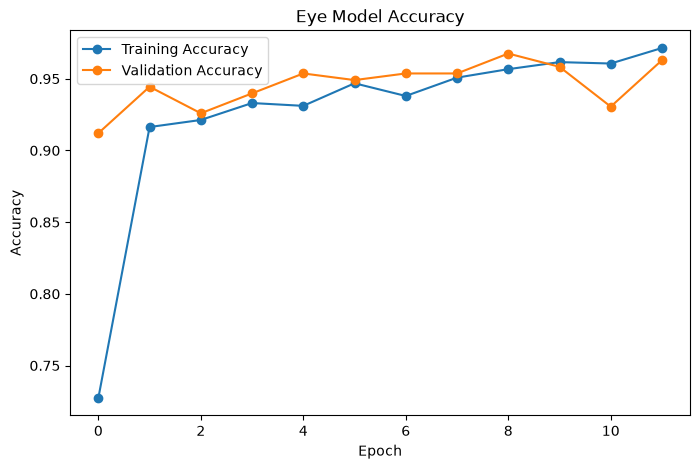

In [20]:
plt.figure(figsize=(8,5))

plt.plot(eye_model_history.history["accuracy"], label = "Training Accuracy", marker="o")

plt.plot(eye_model_history.history["val_accuracy"], label = "Validation Accuracy", marker="o")

plt.title("Eye Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

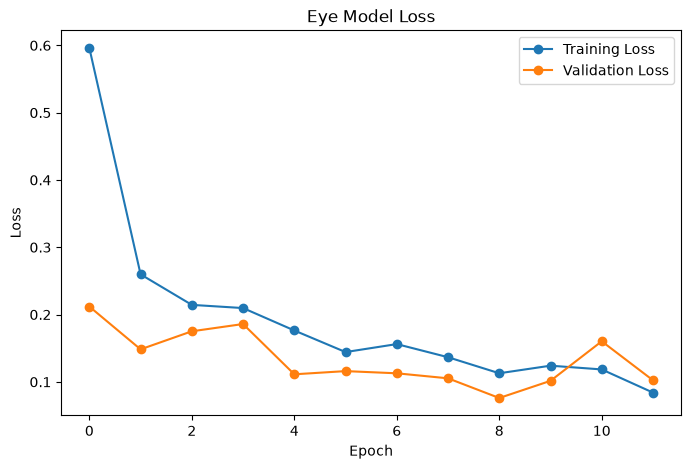

In [21]:
plt.figure(figsize=(8,5))

plt.plot(eye_model_history.history["loss"], label = "Training Loss", marker="o")

plt.plot(eye_model_history.history["val_loss"], label = "Validation Loss", marker="o")

plt.title("Eye Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

---

## Mouth Model Implement

In [22]:
mouth_model = cnn_model(2)

In [23]:
mouth_model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [24]:
mouth_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
mouth_model_history = mouth_model.fit(
    mouth_train_dataset,
    validation_data = mouth_validation_dataset,
    epochs = 20,
    callbacks = [call_back]
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.5499 - loss: 0.8498 - val_accuracy: 0.6204 - val_loss: 0.6353
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6190 - loss: 0.6542 - val_accuracy: 0.6528 - val_loss: 0.6199
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6298 - loss: 0.6176 - val_accuracy: 0.5278 - val_loss: 0.6283
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.6575 - loss: 0.5946 - val_accuracy: 0.6343 - val_loss: 0.6013
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6792 - loss: 0.5758 - val_accuracy: 0.6157 - val_loss: 0.6345
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6792 - loss: 0.5793 - val_accuracy: 0.6806 - val_loss: 0.5845
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6614 - loss: 0.5721 - val_accuracy: 0.6944 - val_loss: 0.5924
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6762 - loss: 0.5730 - val_accuracy: 0.6019 - 

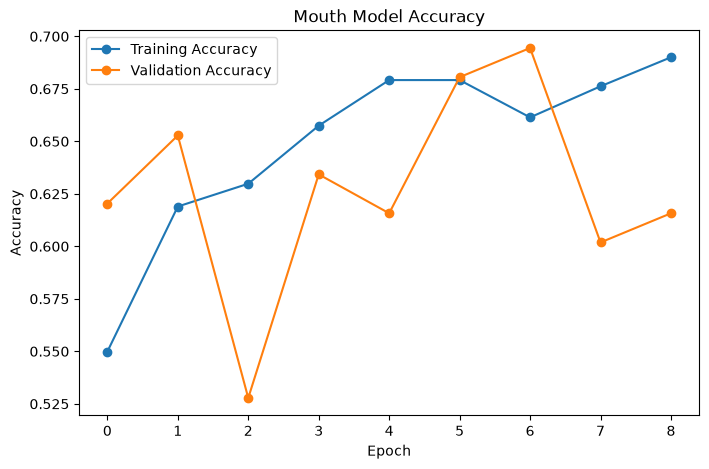

In [26]:
plt.figure(figsize=(8,5))

plt.plot(mouth_model_history.history["accuracy"], label = "Training Accuracy", marker="o")

plt.plot(mouth_model_history.history["val_accuracy"], label = "Validation Accuracy", marker="o")

plt.title("Mouth Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

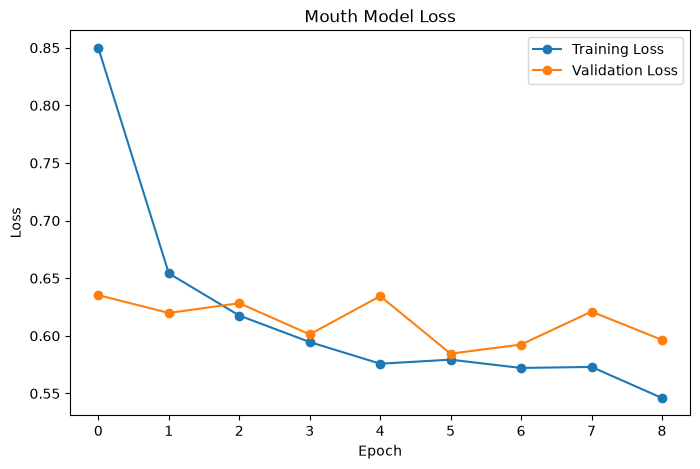

In [27]:
plt.figure(figsize=(8,5))

plt.plot(mouth_model_history.history["loss"], label = "Training Loss", marker="o")

plt.plot(mouth_model_history.history["val_loss"], label = "Validation Loss", marker="o")

plt.title("Mouth Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

---

## Evaluate - Test Data

In [28]:
eye_test_loss, eye_test_accuracy = eye_model.evaluate(eye_test_dataset)

print("Test Accuracy: ", eye_test_accuracy)
print("Test Loss: ", eye_test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9591 - loss: 0.1756
Test Accuracy:  0.9590908885002136
Test Loss:  0.17559686303138733


In [29]:
mouth_test_loss, mouth_test_accuracy = mouth_model.evaluate(mouth_test_dataset)

print("Test Accuracy: ", mouth_test_accuracy)
print("Test Loss: ", mouth_test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6986 - loss: 0.5890
Test Accuracy:  0.698630154132843
Test Loss:  0.5890073180198669


---

## Confusion Matrix and Classification Report

In [30]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

#### Eye Model

In [31]:
eye_predicted = eye_model.predict(eye_test_dataset)

eye_predicted_classes = np.argmax(eye_predicted, axis=1)

eye_true_classes = np.concatenate(
    [np.argmax(labels.numpy(), axis=1) for images, labels in eye_test_dataset]
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


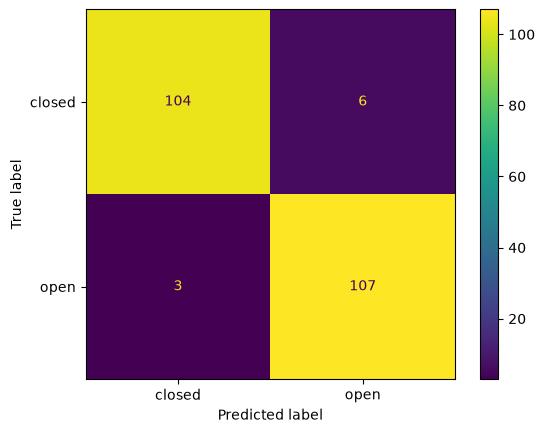

In [32]:
eye_c_matrix = confusion_matrix(
    eye_true_classes,
    eye_predicted_classes
)

ConfusionMatrixDisplay(
    eye_c_matrix,
    display_labels=eye_test_dataset.class_names
).plot()

plt.show()

In [33]:
print(classification_report(
    eye_true_classes,
    eye_predicted_classes,
    target_names=eye_test_dataset.class_names
))

              precision    recall  f1-score   support

      closed       0.97      0.95      0.96       110
        open       0.95      0.97      0.96       110

    accuracy                           0.96       220
   macro avg       0.96      0.96      0.96       220
weighted avg       0.96      0.96      0.96       220



---

### Mouth Model

In [34]:
mouth_predicted = mouth_model.predict(mouth_test_dataset)

mouth_predicted_classes = np.argmax(mouth_predicted, axis=1)

mouth_true_classes = np.concatenate(
    [np.argmax(labels.numpy(), axis=1) for images, labels in mouth_test_dataset]
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


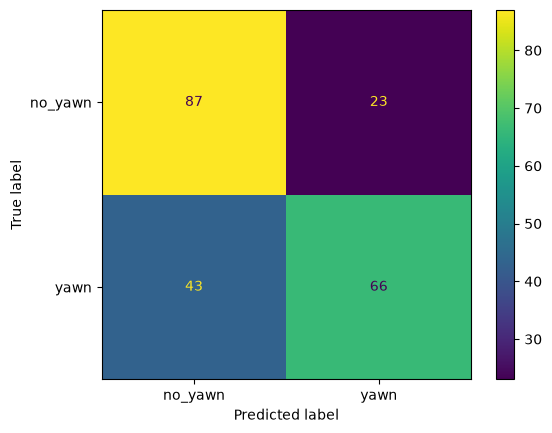

In [35]:
mouth_c_matrix = confusion_matrix(
    mouth_true_classes,
    mouth_predicted_classes
)

ConfusionMatrixDisplay(
    mouth_c_matrix,
    display_labels=mouth_test_dataset.class_names
).plot()

plt.show()

In [36]:
print(classification_report(
    mouth_true_classes,
    mouth_predicted_classes,
    target_names=mouth_test_dataset.class_names
))

              precision    recall  f1-score   support

     no_yawn       0.67      0.79      0.72       110
        yawn       0.74      0.61      0.67       109

    accuracy                           0.70       219
   macro avg       0.71      0.70      0.70       219
weighted avg       0.71      0.70      0.70       219



---

# Accuracy - Eye, Mouth

In [37]:
eye_train_accuracy = eye_model_history.history["accuracy"][-1]
eye_train_loss = eye_model_history.history["loss"][-1]

eye_val_accuracy = eye_model_history.history["val_accuracy"][-1]
eye_val_loss = eye_model_history.history["val_loss"][-1]

mouth_train_accuracy = mouth_model_history.history["accuracy"][-1]
mouth_train_loss = mouth_model_history.history["loss"][-1]

mouth_val_accuracy = mouth_model_history.history["val_accuracy"][-1]
mouth_val_loss = mouth_model_history.history["val_loss"][-1]


print("Eye Model")
print(f"Train Accuracy: {eye_train_accuracy:02f} | Loss: {eye_train_loss:02f}")
print(f"Val Accuracy  : {eye_val_accuracy:02f} | Loss: {eye_val_loss:02f}" )
print(f"Test Accuracy : {eye_test_accuracy:02f} | Loss: {eye_test_loss:02f}")
print()
print("Mouth Model")
print(f"Train Accuracy: {mouth_train_accuracy:02f} | Loss: {mouth_train_loss:02f}")
print(f"Val Accuracy  : {mouth_val_accuracy:02f} | Loss: {mouth_val_loss:02f}")
print(f"Test Accuracy : {mouth_test_accuracy:02f} | Loss: {mouth_test_loss:02f}")

Eye Model
Train Accuracy: 0.971457 | Loss: 0.084045
Val Accuracy  : 0.962963 | Loss: 0.102325
Test Accuracy : 0.959091 | Loss: 0.175597

Mouth Model
Train Accuracy: 0.690030 | Loss: 0.546043
Val Accuracy  : 0.615741 | Loss: 0.596501
Test Accuracy : 0.698630 | Loss: 0.589007


---